# Model Training
Train the Artificial Neural Network (ANN) model.

In [1134]:

import pandas as pd
X_train_scaled= pd.read_csv(
    "processed_data/X_train_scaled.csv"
)
X_test_scaled = pd.read_csv(
    "processed_data/X_test_scaled.csv"
)
y_train = pd.read_csv(
    "processed_data/y_train.csv"
)
y_test = pd.read_csv(
    "processed_data/y_test.csv"
)



In [1135]:
print(X_train_scaled.columns)

Index(['Age', 'self_employed', 'family_history', 'work_interfere',
       'no_employees', 'remote_work', 'tech_company', 'seek_help', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'obs_consequence', 'Gender_Female', 'Gender_Male', 'Gender_Other',
       'care_options_No', 'care_options_Not sure', 'care_options_Yes',
       'benefits_Don't know', 'benefits_No', 'benefits_Yes',
       'wellness_program_Don't know', 'wellness_program_No',
       'wellness_program_Yes', 'anonymity_Don't know', 'anonymity_No',
       'anonymity_Yes', 'mental_vs_physical_Don't know',
       'mental_vs_physical_No', 'mental_vs_physical_Yes',
       'Country_Group_Developed_Asia_Pacific', 'Country_Group_Developing',
       'Country_Group_Other', 'Country_Group_Western_Developed'],
      dtype='object')


In [1136]:
print(y_train.value_counts())

treatment
1            554
0            541
Name: count, dtype: int64


In [1137]:
print(y_test.value_counts())

treatment
1            83
0            81
Name: count, dtype: int64


In [1138]:
!pip install tensorflow

In [1139]:
# Import TensorFlow and train the model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [1140]:
y_train = y_train.squeeze()

y_test = y_test.squeeze()

In [1141]:
# =========================================
# MODEL TRAINING NOTEBOOK
# NeuroScope-AI
# =========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [1142]:
model = Sequential([
    Dense(16, activation='relu',
    kernel_regularizer=l2(0.019),
     input_shape=(X_train_scaled.shape[1],)),
    Dense(8, activation='relu',kernel_regularizer=l2(0.016),),
    
    Dense(1, activation='sigmoid')
])

c:\Users\ADMIN\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [1143]:
!pip install pydot

In [1144]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file='model_structure.png',
    show_shapes=True,
    show_layer_names=True
)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [1145]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [1146]:
model.summary()

Model: "sequential_54"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_164 (Dense)               │ (None, 16)             │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_165 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_166 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

In [1147]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [1148]:
history = model.fit(

    X_train_scaled,
    y_train,

    validation_split=0.25,

    epochs=50,

    
    callbacks=[early_stop]

)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5579 - loss: 1.3105 - val_accuracy: 0.5949 - val_loss: 1.1978
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6224 - loss: 1.1614 - val_accuracy: 0.6606 - val_loss: 1.0959
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6870 - loss: 1.0628 - val_accuracy: 0.6934 - val_loss: 1.0191
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7284 - loss: 0.9850 - val_accuracy: 0.7372 - val_loss: 0.9516
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7625 - loss: 0.9173 - val_accuracy: 0.7664 - val_loss: 0.8918
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7832 - loss: 0.8560 - val_accuracy: 0.7774 - val_loss: 0.8388
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7868 - loss: 0.8014 - val_accuracy: 0.7774 - val_loss: 0.7900
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8149 - loss: 0.7509 - val_accuracy: 0.7664 - val_loss:

In [1149]:
from tensorflow.keras.regularizers import l2

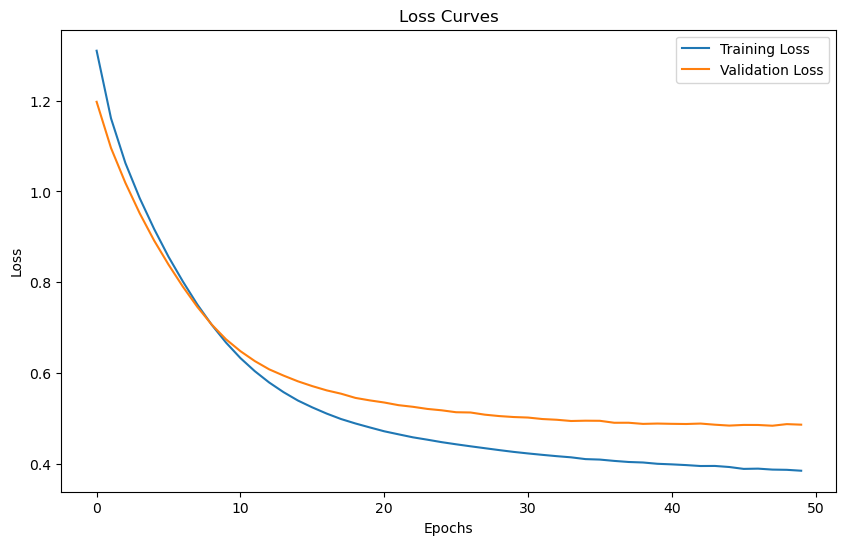

In [1150]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Loss Curves")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.show()

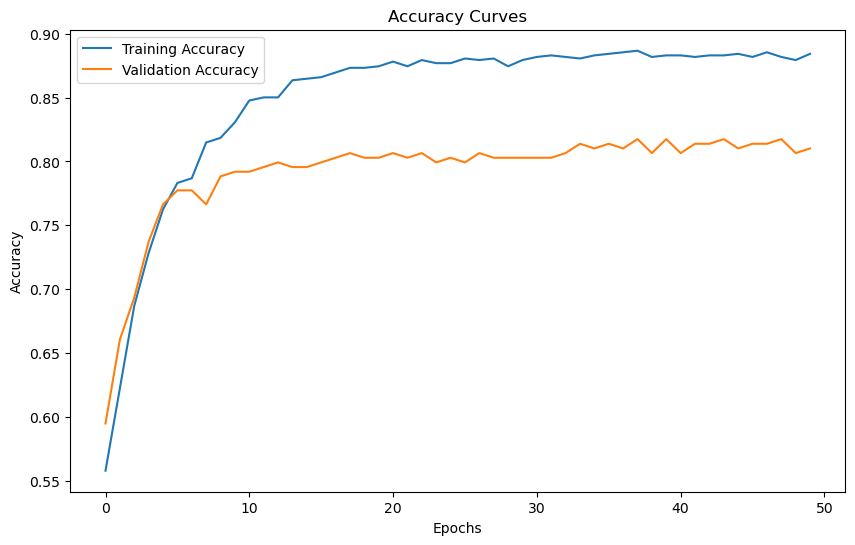

In [1151]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Accuracy Curves")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [1152]:
final_train_acc = history.history['accuracy'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")

Final Training Accuracy: 0.8843


In [1153]:
final_val_acc = history.history['val_accuracy'][-1]

print(f"Final Validation Accuracy: {final_val_acc:.4f}")

Final Validation Accuracy: 0.8102


In [1154]:
print(X_.columns)

NameError: name 'X_' is not defined